一、实验准备：导入库与数据

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.animation as animation
from IPython.display import display, clear_output
import ipywidgets as widgets
from sklearn.datasets import fetch_openml

# 加载波士顿房价数据集（使用 OpenML 镜像，ID=531）
boston = fetch_openml(data_id=531, as_frame=True, parser='auto')
df = boston.data
df['MEDV'] = boston.target

# 选取 RM（平均房间数）作为唯一特征，进行一元线性回归
X = df['RM'].values.reshape(-1, 1)
y = df['MEDV'].values

# 标准化，有利于梯度下降收敛
X_mean, X_std = np.mean(X), np.std(X)
y_mean, y_std = np.mean(y), np.std(y)
X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

print("数据加载完成，共 {} 条样本".format(len(y)))

数据加载完成，共 506 条样本


C:\Users\乔\AppData\Local\Temp\ipykernel_2744\2212616681.py:13: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  plt.tight_layout()
C:\Users\乔\AppData\Local\Temp\ipykernel_2744\2212616681.py:13: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  plt.tight_layout()
C:\Users\乔\AppData\Local\Temp\ipykernel_2744\2212616681.py:13: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from current font.
  plt.tight_layout()
C:\Users\乔\AppData\Local\Temp\ipykernel_2744\2212616681.py:13: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
C:\Users\乔\AppData\Local\Temp\ipykernel_2744\2212616681.py:13: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\乔\AppData\Local\Temp\ipykernel_2744\2212616681.py:13: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.
  plt.t

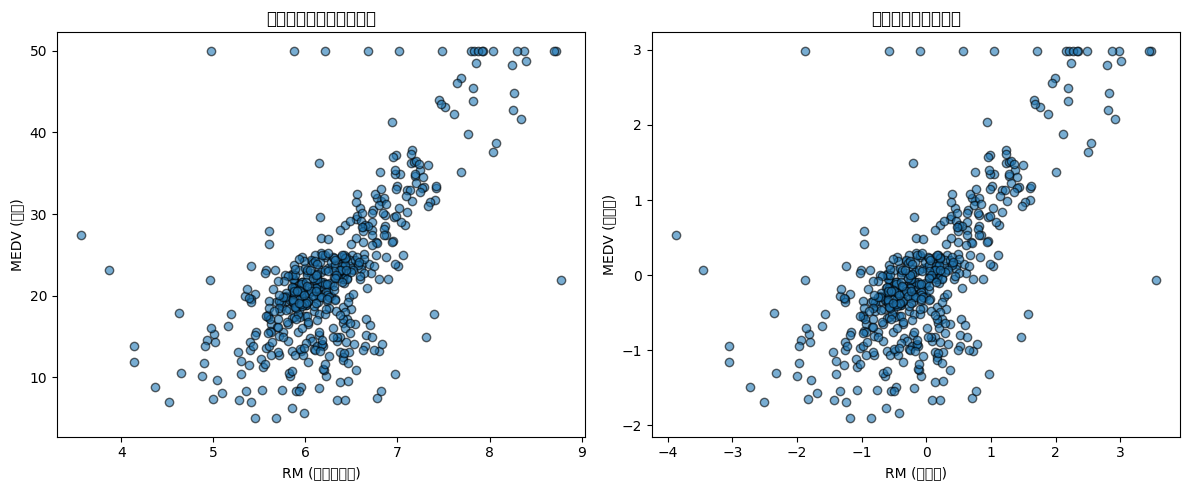

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 原始数据
axes[0].scatter(X, y, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('RM (平均房间数)')
axes[0].set_ylabel('MEDV (房价)')
axes[0].set_title('房价与房间数的原始关系')

# 标准化后数据
axes[1].scatter(X_norm, y_norm, alpha=0.6, edgecolors='k')
axes[1].set_xlabel('RM (标准化)')
axes[1].set_ylabel('MEDV (标准化)')
axes[1].set_title('标准化后的线性关系')
plt.tight_layout()
plt.show()

三、从零实现梯度下降的线性回归类

In [3]:
class LinearRegressionGD:
    """
    一元线性回归 y = w*x + b
    使用批量梯度下降优化均方误差损失
    """
    def __init__(self, lr=0.1, n_iters=1000, random_state=42):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []
        self.w_history = []
        self.b_history = []
        # 设置随机种子，保证可复现
        np.random.seed(random_state)

    def fit(self, X, y):
        n_samples = len(X)
        # 参数初始化（小随机值）
        self.w = np.random.randn() * 0.1
        self.b = 0.0

        for i in range(self.n_iters):
            # 前向计算
            y_pred = X.dot(self.w) + self.b
            # 均方误差损失
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)
            self.w_history.append(self.w)
            self.b_history.append(self.b)

            # 梯度计算
            error = y_pred - y
            dw = (2 / n_samples) * np.sum(X * error)
            db = (2 / n_samples) * np.sum(error)

            # 参数更新
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return X.dot(self.w) + self.b

四、训练与损失曲线观察

c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


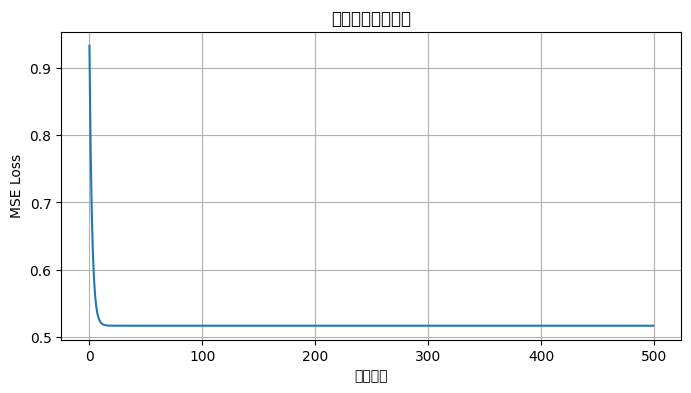

In [4]:
# 使用标准化后的数据训练
model = LinearRegressionGD(lr=0.1, n_iters=500)
model.fit(X_norm.flatten(), y_norm)

# 绘制损失下降曲线
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('迭代次数')
plt.ylabel('MSE Loss')
plt.title('梯度下降损失曲线')
plt.grid(True)
plt.show()

五、参数调优：学习率的影响

c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anon\anon\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


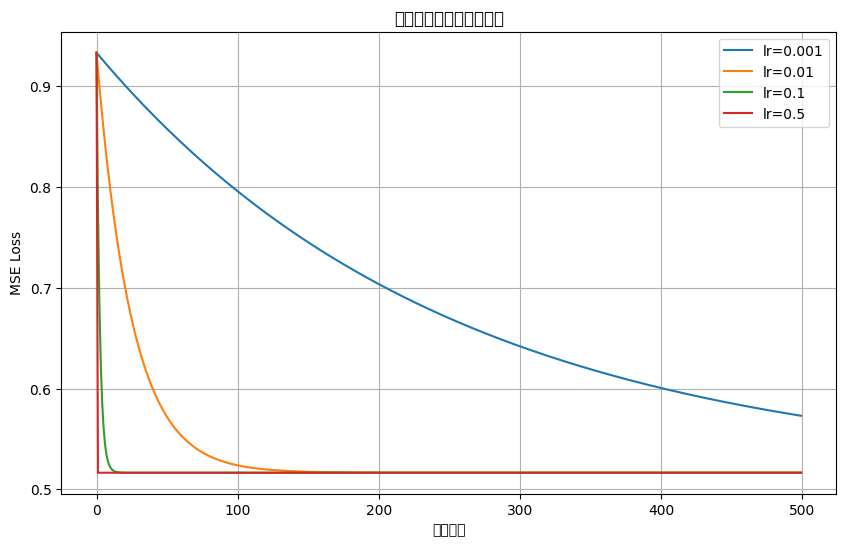

In [5]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    temp_model = LinearRegressionGD(lr=lr, n_iters=500)
    temp_model.fit(X_norm.flatten(), y_norm)
    plt.plot(temp_model.loss_history, label=f'lr={lr}')
plt.xlabel('迭代次数')
plt.ylabel('MSE Loss')
plt.title('不同学习率下的收敛行为')
plt.legend()
plt.grid(True)
plt.show()

六、模型评估：计算 MSE, RMSE, R²

In [6]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

# 预测并反标准化回原始房价尺度
y_pred_norm = model.predict(X_norm.flatten())
y_pred = y_pred_norm * y_std + y_mean
y_true = y

mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 43.60
RMSE: 6.60
R²: 0.4835


七、预测应用

In [7]:
# 输入新的特征值（房间数）并预测房价
def predict_price(rm):
    rm_norm = (rm - X_mean) / X_std
    pred_norm = model.w * rm_norm + model.b
    pred_price = pred_norm * y_std + y_mean
    return pred_price

# 示例：预测房间数为 6 时的房价
room_num = 6.0
price = predict_price(room_num)
print(f"房间数: {room_num}, 预测房价: ${price:.2f} (千美元)")

房间数: 6.0, 预测房价: $19.94 (千美元)


八、可视化与交互设计（核心模块）

In [ ]:
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')

# 若 widget 后端不可用，则自动回退到 inline。

class InteractiveLinearRegression:
    def __init__(self, X, y, X_norm, y_norm, X_mean, X_std, y_mean, y_std):
        self.X = X.flatten()
        self.y = y
        self.X_norm = X_norm.flatten()
        self.y_norm = y_norm
        self.X_mean = X_mean
        self.X_std = X_std
        self.y_mean = y_mean
        self.y_std = y_std

        self.points = np.column_stack((self.X_norm, self.y_norm))
        self.dragging_point = None
        self.old_point = None

        self.lr = 0.1
        self.n_iters = 200
        self.w = 0.0
        self.b = 0.0
        self.w_history = []
        self.b_history = []
        self.loss_history = []
        self.current_step = 0
        self.is_trained = False

        self.setup_ui()
        self.setup_figures()

    def setup_ui(self):
        self.lr_slider = widgets.FloatLogSlider(
            value=0.1, base=10, min=-3, max=0, step=0.01,
            description='学习率:', readout_format='.3f'
        )
        self.iter_slider = widgets.IntSlider(
            value=200, min=10, max=1000, step=10,
            description='迭代次数:'
        )
        self.train_btn = widgets.Button(description='开始训练', button_style='success')
        self.reset_btn = widgets.Button(description='重置', button_style='warning')
        self.animate_btn = widgets.Button(description='播放梯度下降动画', button_style='info')
        self.step_text = widgets.IntText(value=0, description='步数:', disabled=True)

        self.train_btn.on_click(self.train)
        self.reset_btn.on_click(self.reset)
        self.animate_btn.on_click(self.animate_gd)

        self.ui = widgets.VBox([
            widgets.HBox([self.lr_slider, self.iter_slider]),
            widgets.HBox([self.train_btn, self.reset_btn, self.animate_btn]),
            self.step_text,
        ])
        display(self.ui)

    def setup_figures(self):
        self.out = widgets.Output()
        display(self.out)

        with self.out:
            clear_output(wait=True)
            self.fig, self.axs = plt.subplots(2, 2, figsize=(14, 10))
            self.ax_scatter = self.axs[0, 0]
            self.ax_loss = self.axs[0, 1]
            self.ax_contour = self.axs[1, 0]
            self.ax_gauges = self.axs[1, 1]

            self.sc = self.ax_scatter.scatter(
                self.X_norm, self.y_norm,
                c='steelblue', edgecolors='white', s=60, zorder=5
            )
            self.line, = self.ax_scatter.plot([], [], 'r-', lw=2, label='回归线')
            self.residual_lines = []
            self.ax_scatter.set_xlabel('RM (标准化)')
            self.ax_scatter.set_ylabel('MEDV (标准化)')
            self.ax_scatter.set_title('拖拽数据点 -> 回归线实时更新')
            self.ax_scatter.grid(True)
            self.ax_scatter.legend()

            self.fig.canvas.mpl_connect('button_press_event', self.on_press)
            self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
            self.fig.canvas.mpl_connect('button_release_event', self.on_release)

            self.ax_loss.set_title('训练损失')
            self.ax_loss.set_xlabel('迭代')
            self.ax_loss.set_ylabel('MSE')
            self.loss_line, = self.ax_loss.plot([], [], 'b-', lw=2)
            self.ax_loss.grid(True)

            w_range = np.linspace(-1, 2, 100)
            b_range = np.linspace(-1, 2, 100)
            self.W, self.B = np.meshgrid(w_range, b_range)
            self.loss_surface = np.zeros_like(self.W)
            self.compute_loss_surface()
            self.ax_contour.contourf(
                self.W, self.B, self.loss_surface,
                levels=20, cmap='viridis', alpha=0.8
            )
            self.ax_contour.set_xlabel('w')
            self.ax_contour.set_ylabel('b')
            self.ax_contour.set_title('损失函数地形图')
            self.path_scatter, = self.ax_contour.plot([], [], 'r.-', markersize=5, label='参数路径')
            self.ax_contour.legend()

            self.ax_gauges.set_aspect('equal')
            self.ax_gauges.set_title('拟合优度仪表盘')
            self.ax_gauges.axis('off')
            self.draw_gauges(r2=0.0, rmse=0.0)
            plt.tight_layout()
            plt.show()

    def compute_loss_surface(self):
        """计算损失表面 (MSE) 用于等高线。"""
        for i in range(self.W.shape[0]):
            for j in range(self.W.shape[1]):
                w = self.W[i, j]
                b = self.B[i, j]
                y_pred = w * self.X_norm + b
                self.loss_surface[i, j] = np.mean((y_pred - self.y_norm) ** 2)

    def draw_gauges(self, r2, rmse):
        """绘制指针式仪表盘。"""
        self.ax_gauges.clear()
        self.ax_gauges.axis('off')
        self.ax_gauges.set_aspect('equal')
        self._draw_gauge(self.ax_gauges, pos=(0.25, 0.6), val=r2, vmin=0, vmax=1, title='R²', color='green')
        self._draw_gauge(self.ax_gauges, pos=(0.75, 0.6), val=rmse, vmin=0, vmax=10, title='RMSE', color='red')

    def _draw_gauge(self, ax, pos, val, vmin, vmax, title, color):
        """辅助函数画单个半圆仪表。"""
        theta = np.linspace(np.pi, 0, 100)
        x = np.cos(theta) * 0.3 + pos[0]
        y = np.sin(theta) * 0.3 + pos[1] - 0.15
        ax.plot(x, y, 'k-', lw=2)
        angle = np.pi * (1 - (val - vmin) / (vmax - vmin + 1e-6))
        dx = np.cos(angle) * 0.28
        dy = np.sin(angle) * 0.28 - 0.15
        ax.arrow(pos[0], pos[1] - 0.15, dx, dy, head_width=0.02, head_length=0.03, fc=color, ec=color)
        ax.text(
            pos[0], pos[1] - 0.3, f'{title}: {val:.3f}', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )

    def update_scatter_plot(self):
        """根据当前点阵和参数 (w,b) 更新回归线和残差线段。"""
        self.sc.set_offsets(self.points)
        x_vals = np.array([self.X_norm.min(), self.X_norm.max()])
        y_vals = self.w * x_vals + self.b
        self.line.set_data(x_vals, y_vals)

        for rl in self.residual_lines:
            rl.remove()
        self.residual_lines.clear()

        residuals = self.y_norm - (self.w * self.X_norm + self.b)
        max_res = np.max(np.abs(residuals)) if len(residuals) > 0 else 1
        norm = plt.Normalize(-max_res, max_res)
        cmap = plt.cm.RdYlBu_r
        for x, y_true, res in zip(self.X_norm, self.y_norm, residuals):
            y_pred = self.w * x + self.b
            color = cmap(norm(res))
            line = self.ax_scatter.plot([x, x], [y_true, y_pred], color=color, alpha=0.6, linewidth=1)
            self.residual_lines.extend(line)

        y_pred_all = self.w * self.X_norm + self.b
        y_pred_orig = y_pred_all * self.y_std + self.y_mean
        r2 = r2_score(self.y, y_pred_orig)
        rmse = root_mean_squared_error(self.y, y_pred_orig)
        self.draw_gauges(r2, rmse)

    def update_loss_plot(self):
        if self.loss_history:
            steps = np.arange(1, len(self.loss_history) + 1)
            self.loss_line.set_data(steps, self.loss_history)
            self.ax_loss.set_xlim(1, max(10, len(self.loss_history)))
            self.ax_loss.set_ylim(0, max(self.loss_history) * 1.05 if max(self.loss_history) > 0 else 1)

    def fit_from_current_points(self):
        """用当前散点数据重新训练模型。"""
        self.w = np.random.randn() * 0.1
        self.b = 0.0
        self.w_history = []
        self.b_history = []
        self.loss_history = []
        lr = self.lr_slider.value
        n_iters = self.iter_slider.value
        X_use = self.points[:, 0]
        y_use = self.points[:, 1]

        for _ in range(n_iters):
            y_pred = self.w * X_use + self.b
            loss = np.mean((y_pred - y_use) ** 2)
            self.loss_history.append(loss)
            self.w_history.append(self.w)
            self.b_history.append(self.b)
            error = y_pred - y_use
            dw = 2 * np.mean(X_use * error)
            db = 2 * np.mean(error)
            self.w -= lr * dw
            self.b -= lr * db

        self.is_trained = True
        self.current_step = n_iters
        self.update_loss_plot()
        self.update_scatter_plot()
        self.update_contour_path()
        self.fig.canvas.draw_idle()

    def update_contour_path(self):
        if self.w_history:
            self.path_scatter.set_data(self.w_history, self.b_history)
            self.ax_contour.set_title(f'参数路径 (当前步: {self.current_step})')
        self.fig.canvas.draw_idle()

    def train(self, b):
        self.lr = self.lr_slider.value
        self.n_iters = self.iter_slider.value
        self.fit_from_current_points()
        self.step_text.value = self.current_step

    def reset(self, b):
        self.points = np.column_stack((self.X_norm, self.y_norm))
        self.w = 0.0
        self.b = 0.0
        self.w_history = []
        self.b_history = []
        self.loss_history = []
        self.is_trained = False
        self.current_step = 0
        self.step_text.value = 0
        self.loss_line.set_data([], [])
        self.path_scatter.set_data([], [])
        self.update_scatter_plot()
        self.ax_loss.relim()
        self.ax_loss.autoscale_view()
        self.fig.canvas.draw_idle()

    def animate_gd(self, b):
        if not self.is_trained:
            self.train(None)

        def update(frame):
            self.current_step = min(frame, len(self.w_history) - 1)
            self.w = self.w_history[self.current_step]
            self.b = self.b_history[self.current_step]
            self.update_scatter_plot()
            self.path_scatter.set_data(
                self.w_history[:self.current_step + 1],
                self.b_history[:self.current_step + 1]
            )
            self.step_text.value = self.current_step
            return self.line, self.sc, self.path_scatter

        ani = animation.FuncAnimation(
            self.fig, update, frames=len(self.w_history),
            interval=30, blit=False, repeat=False
        )
        from IPython.display import HTML
        display(HTML(ani.to_jshtml()))

    def on_press(self, event):
        if event.inaxes != self.ax_scatter or event.xdata is None or event.ydata is None:
            return
        xy = np.array([event.xdata, event.ydata])
        distances = np.linalg.norm(self.points - xy, axis=1)
        min_idx = np.argmin(distances)
        if distances[min_idx] < 0.1:
            self.dragging_point = min_idx
            self.old_point = self.points[min_idx].copy()

    def on_motion(self, event):
        if self.dragging_point is None or event.inaxes != self.ax_scatter:
            return
        if event.xdata is None or event.ydata is None:
            return

        self.points[self.dragging_point] = [event.xdata, event.ydata]
        self.sc.set_offsets(self.points)

        X_use = self.points[:, 0]
        y_use = self.points[:, 1]
        x_mean = np.mean(X_use)
        y_mean_pt = np.mean(y_use)
        num = np.sum((X_use - x_mean) * (y_use - y_mean_pt))
        den = np.sum((X_use - x_mean) ** 2)
        if den != 0:
            self.w = num / den
            self.b = y_mean_pt - self.w * x_mean

        self.update_scatter_plot()
        self.fig.canvas.draw_idle()

    def on_release(self, event):
        self.dragging_point = None


# 启动交互面板
inter = InteractiveLinearRegression(X, y, X_norm, y_norm, X_mean, X_std, y_mean, y_std)

Output()